In [37]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F


In [38]:
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MNIST_CNN().to(device)
model.load_state_dict(torch.load("mnist_model.pth", map_location=device))
model.eval()


C:\Users\Shail Patel\AppData\Local\Temp\ipykernel_8836\1376409109.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("mnist_model.pth", map

MNIST_CNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)


In [40]:
def preprocess_image(image_path):
    
    image = Image.open(image_path).convert("L")
    
    tensor = transforms.ToTensor()(image)
    
    # Invert (MNIST digits are white on black)
    tensor = 1 - tensor
    
    # Binarize slightly
    tensor = (tensor > 0.3).float()
    
    img = tensor.squeeze()
    coords = torch.nonzero(img)
    
    if coords.shape[0] == 0:
        raise ValueError("No digit detected.")
    
    y_min, x_min = coords.min(dim=0).values
    y_max, x_max = coords.max(dim=0).values
    
    cropped = img[y_min:y_max+1, x_min:x_max+1]
    
    cropped = cropped.unsqueeze(0).unsqueeze(0)
    
    resized = F.interpolate(
        cropped,
        size=(28, 28),
        mode="bilinear",
        align_corners=False
    )
    
    resized = resized.squeeze(0)
    
    # MNIST normalization
    resized = transforms.Normalize((0.1307,), (0.3081,))(resized)
    
    resized = resized.unsqueeze(0)
    
    plt.imshow(tensor.squeeze().cpu(), cmap="gray")
    plt.title("Processed Input")
    plt.show()
    
    return resized.to(device)


In [41]:
def predict(image_path):
    
    tensor = preprocess_image(image_path)
    
    with torch.no_grad():
        outputs = model(tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probs, 1)
    
    return predicted.item(), confidence.item()


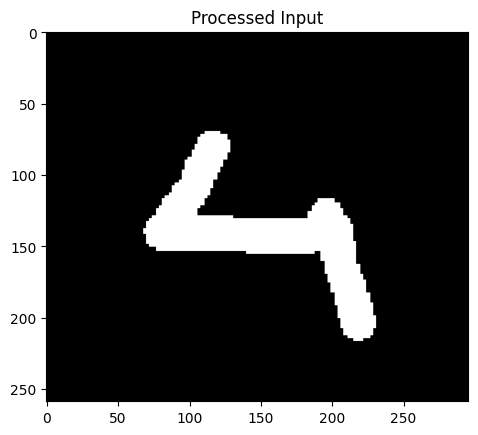

Prediction: 4
Confidence: 0.9633965492248535


In [42]:
digit, conf = predict("images/numbers/digital/single/4.png")
print("Prediction:", digit)
print("Confidence:", conf)
